## Dataset Read

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PATH = "Dataset/Productivity.csv"
df = pd.read_csv(PATH)

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  str    
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  focus_score  

In [5]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [6]:
df.isna().sum()

student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

# Preprocessing

## Removal of Outliers

In [7]:
def check_outliers(df,cols):
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[cols] < lower) | 
              (df[cols] > upper)]
    print("Number of outliers:", len(outliers))
    
    # Visualize
    
    plt.figure(figsize=(8,4))
    plt.title("Before Outlier Removal")
    sns.boxplot(data=df, x=cols)
    plt.axvline(lower, color='red', linestyle='--')
    plt.axvline(upper, color='red', linestyle='--')
    plt.show()

def remove_outliers(df,cols):
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Remove Outliers

    data = df[(df[cols] >= lower) & 
              (df[cols] <= upper)]
    print("Original shape:", df.shape)
    print("After removing outliers:", data.shape)
    

    plt.figure(figsize=(8,4))
    sns.boxplot(x=data[cols])
    plt.title("After Outlier Removal")
    plt.show()
    
    return data

Enter the name of columns for checking and removing outliers: productivity_score


Number of outliers: 18


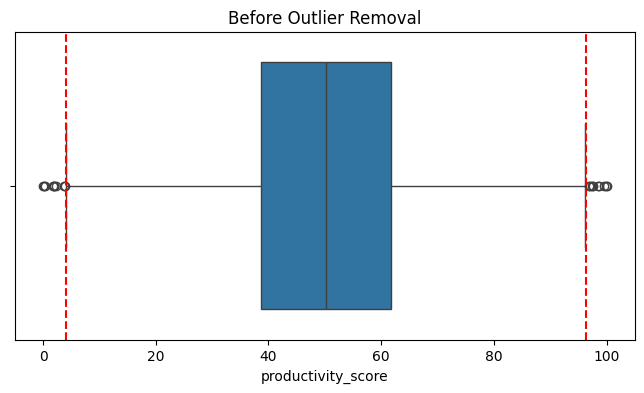

None
Original shape: (20000, 18)
After removing outliers: (19982, 18)


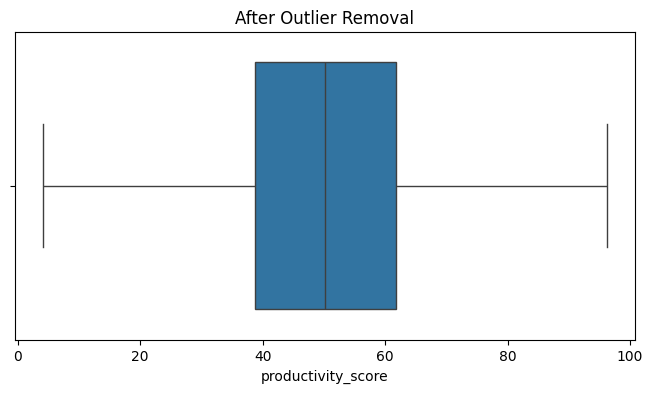

       student_id  age  gender  study_hours_per_day  sleep_hours  \
0               1   23  Female                 4.35         3.63   
1               2   20    Male                 6.14         6.58   
2               3   29  Female                 4.98         3.26   
3               4   27  Female                 3.19         4.58   
4               5   24    Male                 7.67         6.21   
...           ...  ...     ...                  ...          ...   
19995       19996   26  Female                 4.81         7.83   
19996       19997   22   Other                 0.83         4.49   
19997       19998   25    Male                 9.36         4.33   
19998       19999   22  Female                 0.74         4.44   
19999       20000   19  Female                 3.64         6.35   

       phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
0                   3.38                2.73           1.83          5.26   
1                   5.48     

In [8]:
col_name = input('Enter the name of columns for checking and removing outliers:')
print(check_outliers(df,col_name))
data = remove_outliers(df,col_name)
print(data)

## Taking Some information from the dataset

In [9]:
def min_max_hours_taken_in_activities(df):
    for cols in df.columns[3:10]:
        print("---------# For",cols,'#-------------')
        print("Maximum no. of",cols ," in this dataset :",df[cols].max())
        print("Minimum no. of",cols ,"in this dataset :",df[cols].min())

print(min_max_hours_taken_in_activities(data))

---------# For study_hours_per_day #-------------
Maximum no. of study_hours_per_day  in this dataset : 10.0
Minimum no. of study_hours_per_day in this dataset : 0.5
---------# For sleep_hours #-------------
Maximum no. of sleep_hours  in this dataset : 10.0
Minimum no. of sleep_hours in this dataset : 3.0
---------# For phone_usage_hours #-------------
Maximum no. of phone_usage_hours  in this dataset : 12.0
Minimum no. of phone_usage_hours in this dataset : 0.5
---------# For social_media_hours #-------------
Maximum no. of social_media_hours  in this dataset : 8.0
Minimum no. of social_media_hours in this dataset : 0.0
---------# For youtube_hours #-------------
Maximum no. of youtube_hours  in this dataset : 6.0
Minimum no. of youtube_hours in this dataset : 0.0
---------# For gaming_hours #-------------
Maximum no. of gaming_hours  in this dataset : 6.0
Minimum no. of gaming_hours in this dataset : 0.0
---------# For breaks_per_day #-------------
Maximum no. of breaks_per_day  in 

# Feature Extraction

In [11]:
data['total_distraction_hours'] = (
    data['phone_usage_hours'] +
    data['social_media_hours'] +
    data['youtube_hours'] +
    data['gaming_hours']
)

In [12]:
data['study_efficiency'] = data['assignments_completed'] / data['study_hours_per_day']

In [13]:
data['balance_score'] = data['sleep_hours'] + data['exercise_minutes']/60

In [14]:
data['caffeine_sleep_ratio'] = data['coffee_intake_mg'] / (data['sleep_hours'] + 1)

In [15]:
data['engagement_score'] = (
    data['attendance_percentage'] * data['assignments_completed']
)

In [16]:
data

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,...,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,total_distraction_hours,study_efficiency,balance_score,caffeine_sleep_ratio,engagement_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,...,57.21,10,57,81.87,33.78,13.20,0.459770,5.480000,74.946004,114.42
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,...,91.27,10,49,60.90,48.99,11.85,1.628664,7.046667,53.166227,912.70
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,...,63.14,2,38,86.22,36.60,13.35,1.606426,4.960000,98.356808,505.12
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,...,40.51,6,50,71.77,19.87,22.28,5.642633,5.046667,31.899642,729.18
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,...,45.53,6,41,90.13,52.90,15.72,0.912647,7.960000,60.471567,318.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,...,63.69,3,89,82.13,60.43,22.24,2.286902,7.830000,51.075878,700.59
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,...,74.06,10,56,87.12,17.84,14.88,4.819277,4.706667,68.306011,296.24
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,...,73.18,9,69,81.58,65.56,11.69,1.175214,4.346667,77.485929,804.98
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,...,77.02,5,53,53.04,28.06,17.26,8.108108,4.456667,58.639706,462.12


In [17]:
data.to_csv('cleaned_data.csv',index=False)